# BERT Target Linearity — Layer-wise Comparison
Compares target linearity across layers for: initialized, pre-trained, and fine-tuned checkpoints.

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path('..').resolve()

# ── Config ────────────────────────────────────────────────────────────────────
MODEL_SIZE = 'base'   # 'base' | 'large'
TASKS      = ['sst2', 'mnli', 'pos', 'ner']
# ─────────────────────────────────────────────────────────────────────────────

task_data = {}
for task in TASKS:
    result_path = ROOT / 'result' / 'bert' / MODEL_SIZE / task / 'target_linearity.json'
    with open(result_path) as f:
        task_data[task] = json.load(f)

print(f'Model: bert-{MODEL_SIZE}')
for task, data in task_data.items():
    print(f'  {task}: {len(data["checkpoint"])} checkpoints, {len(data["layers"])} layers')

Model: bert-base
  sst2: 5 checkpoints, 13 layers
  mnli: 5 checkpoints, 13 layers
  pos: 5 checkpoints, 13 layers
  ner: 5 checkpoints, 13 layers


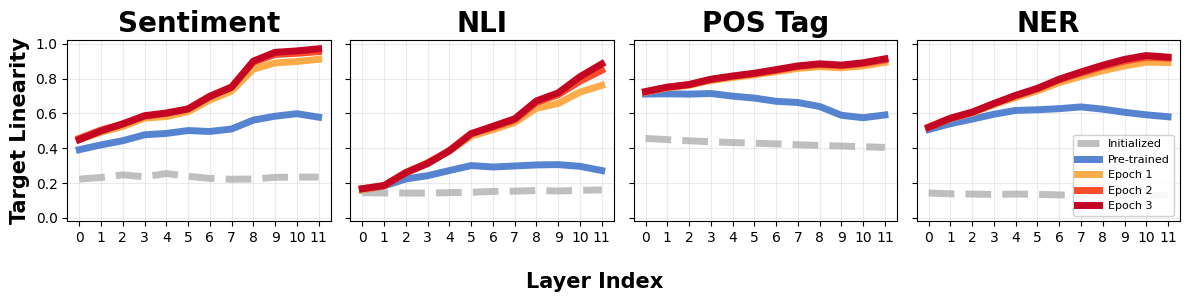

Saved → plot/bert_base_target_linearity.png


In [34]:
TASK_TITLES = {
    'sst2': 'Sentiment',
    'mnli': 'NLI',
    'pos':  'POS Tag',
    'ner':  'NER',
}

fig, axes = plt.subplots(1, 4, figsize=(12, 3), sharey=True)

for ax, task in zip(axes, TASKS):
    data        = task_data[task]
    checkpoints = data['checkpoint']
    layers      = data['layers']
    tl_matrix   = data['target_linearity']

    epoch_ckpts  = [c for c in checkpoints if c.startswith('epoch')]
    n_epochs     = len(epoch_ckpts)
    epoch_colors = plt.cm.YlOrRd(np.linspace(0.4, 0.85, max(n_epochs, 1)))

    color_map = {'init': '#aaaaaa', 'pretrained': '#4477cc'}
    style_map = {
        'init':       dict(linestyle='--', linewidth=5.0, alpha=0.75),
        'pretrained': dict(linestyle='-',  linewidth=5.0, alpha=0.9),
    }
    label_map = {'init': 'Initialized', 'pretrained': 'Pre-trained'}

    for i, ck in enumerate(epoch_ckpts):
        ep = int(ck.replace('epoch', ''))
        color_map[ck] = epoch_colors[i]
        style_map[ck] = dict(linestyle='-', linewidth=5.0)
        label_map[ck] = f'Fine-tuned epoch {ep}'

    x        = np.arange(len(layers)-1)
    x_labels = [str(i) for i in range(len(layers) - 1)]

    for ck, tl in zip(checkpoints, tl_matrix):
        ax.plot(
            x, tl[1:],
            color=color_map[ck],
            label=label_map.get(ck, ck).replace('Fine-tuned ', '').capitalize(),
            **style_map.get(ck, dict(linestyle='-', linewidth=5.0, alpha=0.9)),
        )

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=10)
    # ax.set_xlabel('Layer', fontsize=12, fontweight='bold')
    ax.set_title(TASK_TITLES[task], fontsize=20, fontweight='bold')
    ax.set_ylim(-0.02, 1.02)
    if task == 'ner':
        ax.legend(fontsize=8, loc='lower right', framealpha=0.9)
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel('Target Linearity', fontsize=15, fontweight='bold')

fig.supxlabel('Layer Index', fontsize=15, fontweight='bold')

# fig.suptitle(
#     f'BERT-{MODEL_SIZE.capitalize()} — Target Linearity per Layer',
#     fontsize=15, fontweight='bold',
# )

plt.tight_layout()

out_path = ROOT / 'plot' / f'bert_{MODEL_SIZE}_target_linearity.png'
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved → {out_path.relative_to(ROOT)}')